### Homework 3 Problem 1:

- Create a 2x2 figure with a **total** of four plots exploring families of surfaces created with functions f(x,y). 
- For example, you could explore the impact of multiplying, dividing, adding, and subtracting sine and cosine functions -- but you can choose whatever families of functions you would like. You can choose to display the results using any of the options we explored today: **surface plots, images, and contour plots**. 
- Please also make the plots look professional by modifying the defaults e.g. add axis labels, change font sizes, change aspect ratios, color schemes, etc. Do some research on your own to figure out how to change different aspects of the plots.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#creating a grid
x = np.arange(-3, 3, 0.03)
y = np.arange(-3, 3, 0.03)
X, Y = np.meshgrid(x, y) 

In [4]:
#making the functions
f1 = np.sin(X) * np.cos(Y)
f2 = np.sin(X + Y)
f3 = np.cos(X) - np.sin(Y)
f4 = np.sin(X**2 + Y**2)

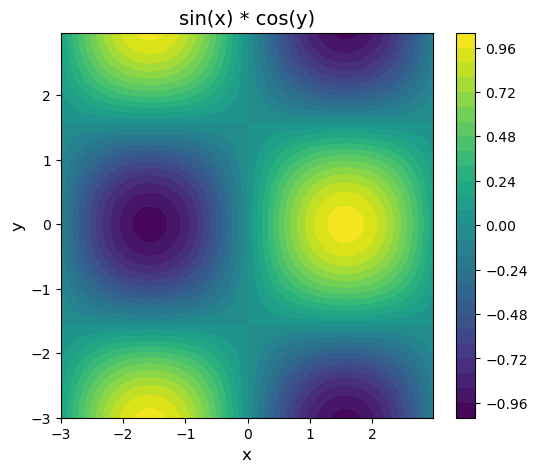

In [5]:
#plotting sin(x)*cos(x)
plt.figure(figsize=(6, 5))
cf1 = plt.contourf(X, Y, f1, levels=30, cmap='viridis')
plt.title('sin(x) * cos(y)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.colorbar(cf1)
plt.show()

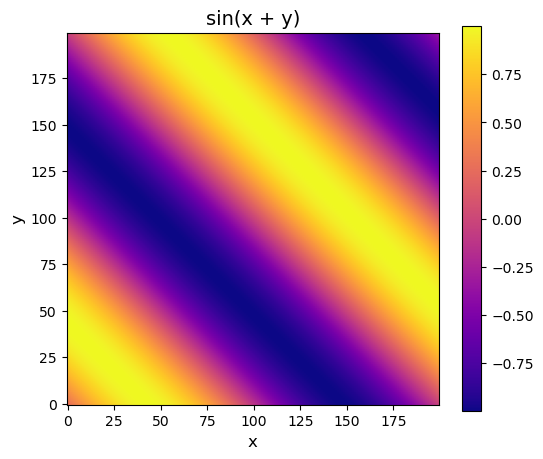

In [8]:
plt.figure(figsize=(6, 5))
im2 = plt.imshow(f2, origin='lower', cmap='plasma')
plt.title('sin(x + y)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.colorbar(im2)
plt.show()

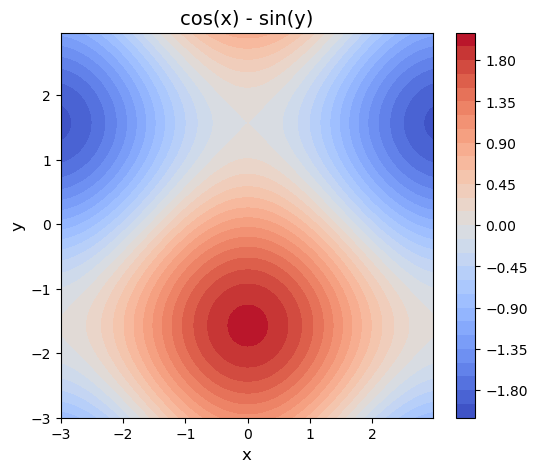

In [9]:
plt.figure(figsize=(6, 5))
cf3 = plt.contourf(X, Y, f3, levels=30, cmap='coolwarm')
plt.title('cos(x) - sin(y)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.colorbar(cf3)
plt.show()

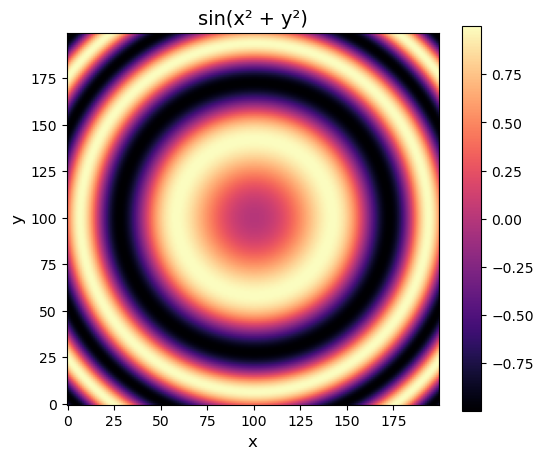

In [10]:
plt.figure(figsize=(6, 5))
im4 = plt.imshow(f4, origin='lower', cmap='magma')
plt.title('sin(x² + y²)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.colorbar(im4)
plt.show()

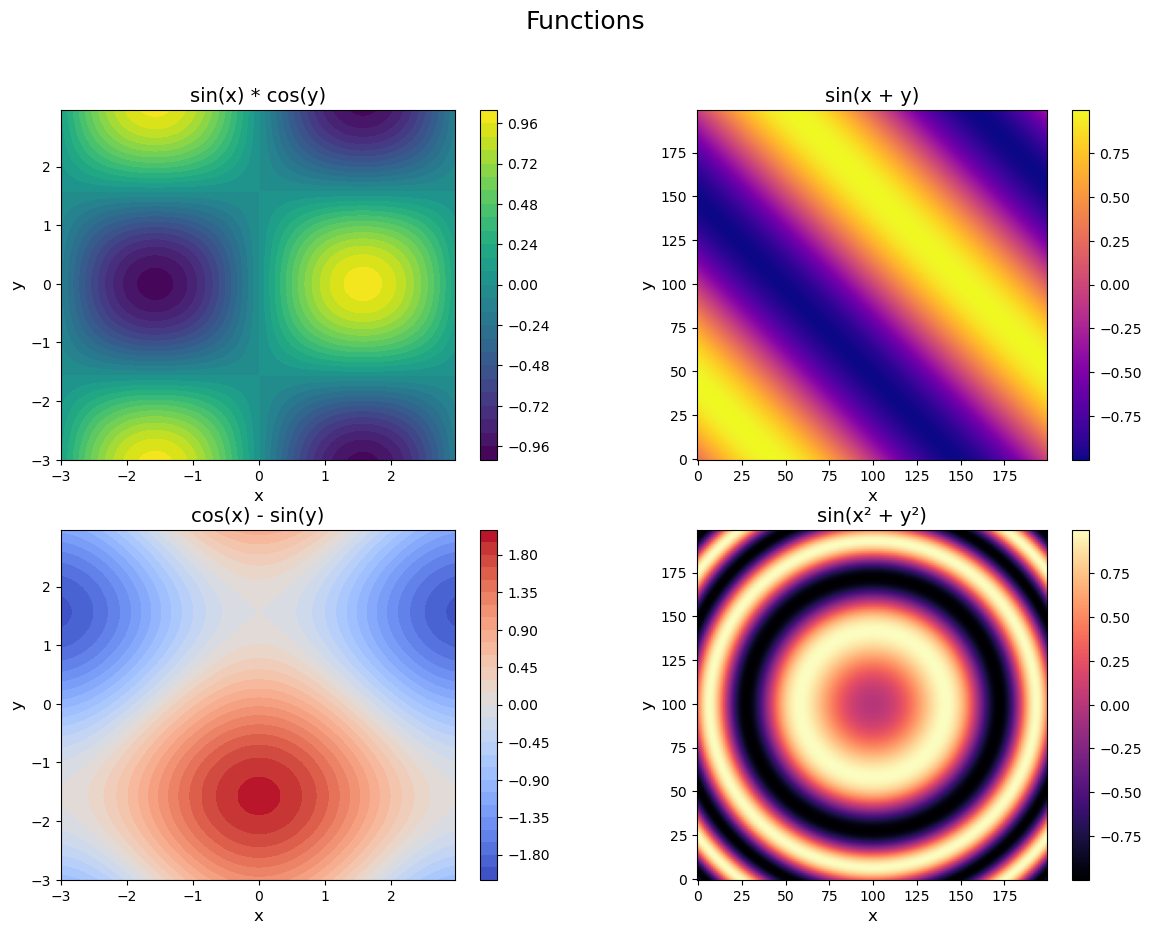

In [15]:
#brining everything together
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

cf1 = axs[0, 0].contourf(X, Y, f1, levels=30, cmap='viridis')
axs[0, 0].set_title('sin(x) * cos(y)', fontsize=14)
axs[0, 0].set_xlabel('x', fontsize=12)
axs[0, 0].set_ylabel('y', fontsize=12)
fig.colorbar(cf1, ax=axs[0, 0])

im2 = axs[0, 1].imshow(f2, origin='lower', cmap='plasma')
axs[0, 1].set_title('sin(x + y)', fontsize=14)
axs[0, 1].set_xlabel('x', fontsize=12)
axs[0, 1].set_ylabel('y', fontsize=12)
fig.colorbar(im2, ax=axs[0, 1])

cf3 = axs[1, 0].contourf(X, Y, f3, levels=30, cmap='coolwarm')
axs[1, 0].set_title('cos(x) - sin(y)', fontsize=14)
axs[1, 0].set_xlabel('x', fontsize=12)
axs[1, 0].set_ylabel('y', fontsize=12)
fig.colorbar(cf3, ax=axs[1, 0])

im4 = axs[1, 1].imshow(f4, origin='lower', cmap='magma')
axs[1, 1].set_title('sin(x² + y²)', fontsize=14)
axs[1, 1].set_xlabel('x', fontsize=12)
axs[1, 1].set_ylabel('y', fontsize=12)
fig.colorbar(im4, ax=axs[1, 1])

plt.suptitle('Functions', fontsize=18)
plt.show()

### Homework 3 Problem 2:

Reusing the `consumer_price_index.csv` data, you would like to create an interactive visualization to explore multiple aspects of the data, rather than a grid of static plots. Please create an interactive plot for the data that uses an appropriate widget to select **multiple** consumer products e.g. lamb, beef, and chicken, from a list of all possible consumer products in the dataset. Your plot should also incorporate at least two other widgets to control some other aspect of the plot e.g. x and y limits, interval size, color, linewidth, etc. Please also be sure to include a legend for interpretability. 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

In [17]:
headers = np.genfromtxt('consumer_price_index.csv', delimiter=',', dtype='str')[0, :]
data = np.genfromtxt('consumer_price_index.csv', delimiter=',', skip_header=1)
years = data[:, 0]


In [18]:
product_names = []
for h in headers:
    if h != 'Year':
        product_names.append(h)

In [ ]:

product_selector = widgets.SelectMultiple(
    options=product_names,
    value=[product_names[0]],
    description='Products',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

x_min_slider = widgets.IntSlider(
    value=int(years.min()),
    min=int(years.min()),
    max=int(years.max())-1,
    step=1,
    description='X min (Year)'
)

x_max_slider = widgets.IntSlider(
    value=int(years.max()),
    min=int(years.min())+1,
    max=int(years.max()),
    step=1,
    description='X max (Year)'
)

color_picker = widgets.ColorPicker(
    value='#1f77b4',
    description='Line Color'
)

linewidth_slider = widgets.FloatSlider(
    value=2.0,
    min=0.5,
    max=5.0,
    step=0.1,
    description='Line Width'
)

box = widgets.VBox([
    product_selector,
    widgets.HBox([x_min_slider, x_max_slider]),
    widgets.HBox([color_picker, linewidth_slider])
])

out = widgets.interactive_output(
    plot_cpi,
    {
        'products': product_selector,
        'x_min': x_min_slider,
        'x_max': x_max_slider,
        'color': color_picker,
        'linewidth': linewidth_slider
    }
)

display(box, out)

Output()

### Problem 3 Reflection 

On every homework assignment. This should be at least 5 sentences and demonstrate engagement with the material that goes beyond "this was hard" or "this was cool." Things you may include are:

- What was most challenging and why
- How you approached a problem
- What you learned outside of class on your own
- How material complements what you are learning in other classes
- Feel free to take it any direction you want, but it needs to meet the above criteria to get full credit


# AI Acknowledgement Statement

Please indicate if and how you used ChatGPT or other LLMs on this assignment. Use the option that best fits your use case:

* [ ] I did not use ChatGPT/LLMs.
* [X] I consulted ChatGPT/LLMs (to brainstorm, to debug, to get information, to give feedback), but I did not copy and paste or use text directly from ChatGPT/LLMs.
* [ ] I copied and pasted portions of code directly from ChatGPT/LLMs.
* [ ] I consulted other outside sources other than ChatGPT/LLMs.